In [9]:
# import os
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# from pathlib import Path
# from tqdm import tqdm

# from sklearn.metrics import classification_report
# from skimage.feature import graycomatrix, graycoprops

Pakai CLAHE

In [10]:
# import os
# from pathlib import Path

# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # ── Konfigurasi ──────────────────────────────────────────────
# DATASET_DIR   = Path("Dataset")

# RANDOM_SEED   = 42
# np.random.seed(RANDOM_SEED)

# # Daftar kelas (sub-folder)
# CLASS_NAMES = sorted([
#     d for d in os.listdir(DATASET_DIR)
#     if (DATASET_DIR / d).is_dir()
# ])

# print("Kelas ditemukan:", CLASS_NAMES)
# print("Jumlah kelas   :", len(CLASS_NAMES))


# # =========================
# # 1) CLAHE pada channel V
# # =========================
# def apply_clahe_v(image_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
#     hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
#     h, s, v = cv2.split(hsv)

#     clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
#     v = clahe.apply(v)

#     hsv_clahe = cv2.merge([h, s, v])
#     return cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2BGR)


# # =========================
# # 2) Segmentasi background hitam dengan HSV
# # =========================
# def segment_money_hsv(
#     image_bgr,
#     v_threshold=25,
#     s_threshold=15,
#     min_area_ratio=0.01,
#     kernel_size=7,
#     use_clahe=True
# ):
#     """
#     Segmentasi uang dari background hitam.
#     Output:
#     - enhanced_img : citra setelah CLAHE (jika dipakai)
#     - refined_mask : mask biner area uang
#     - result       : citra yang sudah dimasking
#     """
#     if image_bgr is None:
#         raise ValueError("Gambar tidak berhasil dibaca.")

#     enhanced_img = image_bgr.copy()
#     if use_clahe:
#         enhanced_img = apply_clahe_v(enhanced_img)

#     hsv = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2HSV)

#     # Ambil piksel yang tidak terlalu gelap
#     mask_v = cv2.inRange(
#         hsv,
#         np.array([0, 0, v_threshold]),
#         np.array([180, 255, 255])
#     )

#     # Saring piksel yang terlalu kusam
#     mask_s = cv2.inRange(
#         hsv,
#         np.array([0, s_threshold, 0]),
#         np.array([180, 255, 255])
#     )

#     mask = cv2.bitwise_and(mask_v, mask_s)

#     # Morphological cleaning
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
#     mask = cv2.medianBlur(mask, 5)

#     # Ambil komponen terbesar
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
#     refined = np.zeros_like(mask)

#     if num_labels > 1:
#         areas = stats[1:, cv2.CC_STAT_AREA]
#         largest_idx = 1 + np.argmax(areas)
#         largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

#         h, w = mask.shape[:2]
#         min_area = int(min_area_ratio * h * w)

#         if largest_area >= min_area:
#             refined[labels == largest_idx] = 255
#         else:
#             refined = mask.copy()
#     else:
#         refined = mask.copy()

#     result = cv2.bitwise_and(enhanced_img, enhanced_img, mask=refined)
#     return enhanced_img, refined, result


# # =========================
# # 3) Crop berdasarkan mask
# # =========================
# def crop_to_mask(image_bgr, mask, padding=15):
#     coords = cv2.findNonZero(mask)
#     if coords is None:
#         return image_bgr

#     x, y, w, h = cv2.boundingRect(coords)
#     h_img, w_img = image_bgr.shape[:2]

#     x1 = max(x - padding, 0)
#     y1 = max(y - padding, 0)
#     x2 = min(x + w + padding, w_img)
#     y2 = min(y + h + padding, h_img)

#     return image_bgr[y1:y2, x1:x2]


# # =========================
# # 4) Contoh penggunaan
# # =========================
# # Ambil salah satu gambar dari kelas pertama
# sample_class = CLASS_NAMES[0]
# sample_path = DATASET_DIR / sample_class

# sample_files = sorted([
#     f for f in os.listdir(sample_path)
#     if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
# ])

# img_path = sample_path / sample_files[0]
# img = cv2.imread(str(img_path))

# enhanced, mask, segmented = segment_money_hsv(
#     img,
#     v_threshold=25,
#     s_threshold=15,
#     min_area_ratio=0.01,
#     kernel_size=7,
#     use_clahe=True
# )

# cropped = crop_to_mask(segmented, mask, padding=15)

# # Tampilkan hasil
# fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# axes[0].set_title("Original")

# axes[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
# axes[1].set_title("After CLAHE")

# # axes[2].imshow(mask, cmap="gray")
# # axes[2].set_title("HSV Mask")

# axes[3].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
# axes[3].set_title("Cropped Result")

# for ax in axes:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

# Tanpa CLAHE 

In [11]:
# import os
# from pathlib import Path

# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # ── Konfigurasi ──────────────────────────────────────────────
# DATASET_DIR = Path("Dataset")

# RANDOM_SEED = 42
# np.random.seed(RANDOM_SEED)

# CLASS_NAMES = sorted([
#     d for d in os.listdir(DATASET_DIR)
#     if (DATASET_DIR / d).is_dir()
# ])

# print("Kelas ditemukan:", CLASS_NAMES)
# print("Jumlah kelas   :", len(CLASS_NAMES))


# # =========================
# # 1) CLAHE pada channel V
# # =========================
# def apply_clahe_v(image_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
#     hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
#     h, s, v = cv2.split(hsv)

#     clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
#     v = clahe.apply(v)

#     hsv_clahe = cv2.merge([h, s, v])
#     return cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2BGR)


# # =========================
# # 2) Segmentasi berdasarkan intensitas gelap
# # =========================
# def segment_money_dark_bg(
#     image_bgr,
#     gray_threshold=25,
#     min_area_ratio=0.01,
#     kernel_size=7,
#     use_clahe=False
# ):
#     """
#     Segmentasi objek uang dari background hitam.
#     Strategi:
#     - threshold grayscale untuk memisahkan area terang dari background gelap
#     - morphological cleaning
#     - ambil komponen terbesar
#     """
#     if image_bgr is None:
#         raise ValueError("Gambar tidak berhasil dibaca.")

#     work_img = image_bgr.copy()

#     # CLAHE jangan dipakai dulu untuk masking, karena bisa memperumit pemisahan background
#     if use_clahe:
#         work_img = apply_clahe_v(work_img)

#     gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)

#     # Piksel yang lebih terang dari background dianggap objek
#     _, mask = cv2.threshold(gray, gray_threshold, 255, cv2.THRESH_BINARY)

#     # Morphological cleaning
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

#     # Isi lubang di dalam objek
#     h, w = mask.shape[:2]
#     flood = mask.copy()
#     flood_mask = np.zeros((h + 2, w + 2), np.uint8)
#     cv2.floodFill(flood, flood_mask, (0, 0), 255)
#     flood_inv = cv2.bitwise_not(flood)
#     mask = mask | flood_inv

#     # Ambil komponen terbesar
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
#     refined = np.zeros_like(mask)

#     if num_labels > 1:
#         areas = stats[1:, cv2.CC_STAT_AREA]
#         largest_idx = 1 + np.argmax(areas)
#         largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

#         min_area = int(min_area_ratio * h * w)

#         if largest_area >= min_area:
#             refined[labels == largest_idx] = 255
#         else:
#             refined = mask.copy()
#     else:
#         refined = mask.copy()

#     result = cv2.bitwise_and(work_img, work_img, mask=refined)
#     return work_img, refined, result


# # =========================
# # 3) Crop berdasarkan mask
# # =========================
# def crop_to_mask(image_bgr, mask, padding=15):
#     coords = cv2.findNonZero(mask)
#     if coords is None:
#         return image_bgr

#     x, y, w, h = cv2.boundingRect(coords)
#     h_img, w_img = image_bgr.shape[:2]

#     x1 = max(x - padding, 0)
#     y1 = max(y - padding, 0)
#     x2 = min(x + w + padding, w_img)
#     y2 = min(y + h + padding, h_img)

#     return image_bgr[y1:y2, x1:x2]


# # =========================
# # 4) Contoh penggunaan
# # =========================
# sample_class = CLASS_NAMES[0]
# sample_path = DATASET_DIR / sample_class

# sample_files = sorted([
#     f for f in os.listdir(sample_path)
#     if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
# ])

# img_path = sample_path / sample_files[0]
# img = cv2.imread(str(img_path))

# work_img, mask, segmented = segment_money_dark_bg(
#     img,
#     gray_threshold=25,
#     min_area_ratio=0.01,
#     kernel_size=7,
#     use_clahe=False
# )

# cropped = crop_to_mask(segmented, mask, padding=15)

# fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# axes[0].set_title("Original")

# axes[1].imshow(cv2.cvtColor(work_img, cv2.COLOR_BGR2RGB))
# axes[1].set_title("Work Image")

# axes[2].imshow(mask, cmap="gray")
# axes[2].set_title("Mask")

# axes[3].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
# axes[3].set_title("Cropped Result")

# for ax in axes:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

Kelas ditemukan: ['10k', '20k', '2k', '5k']
Jumlah kelas   : 4


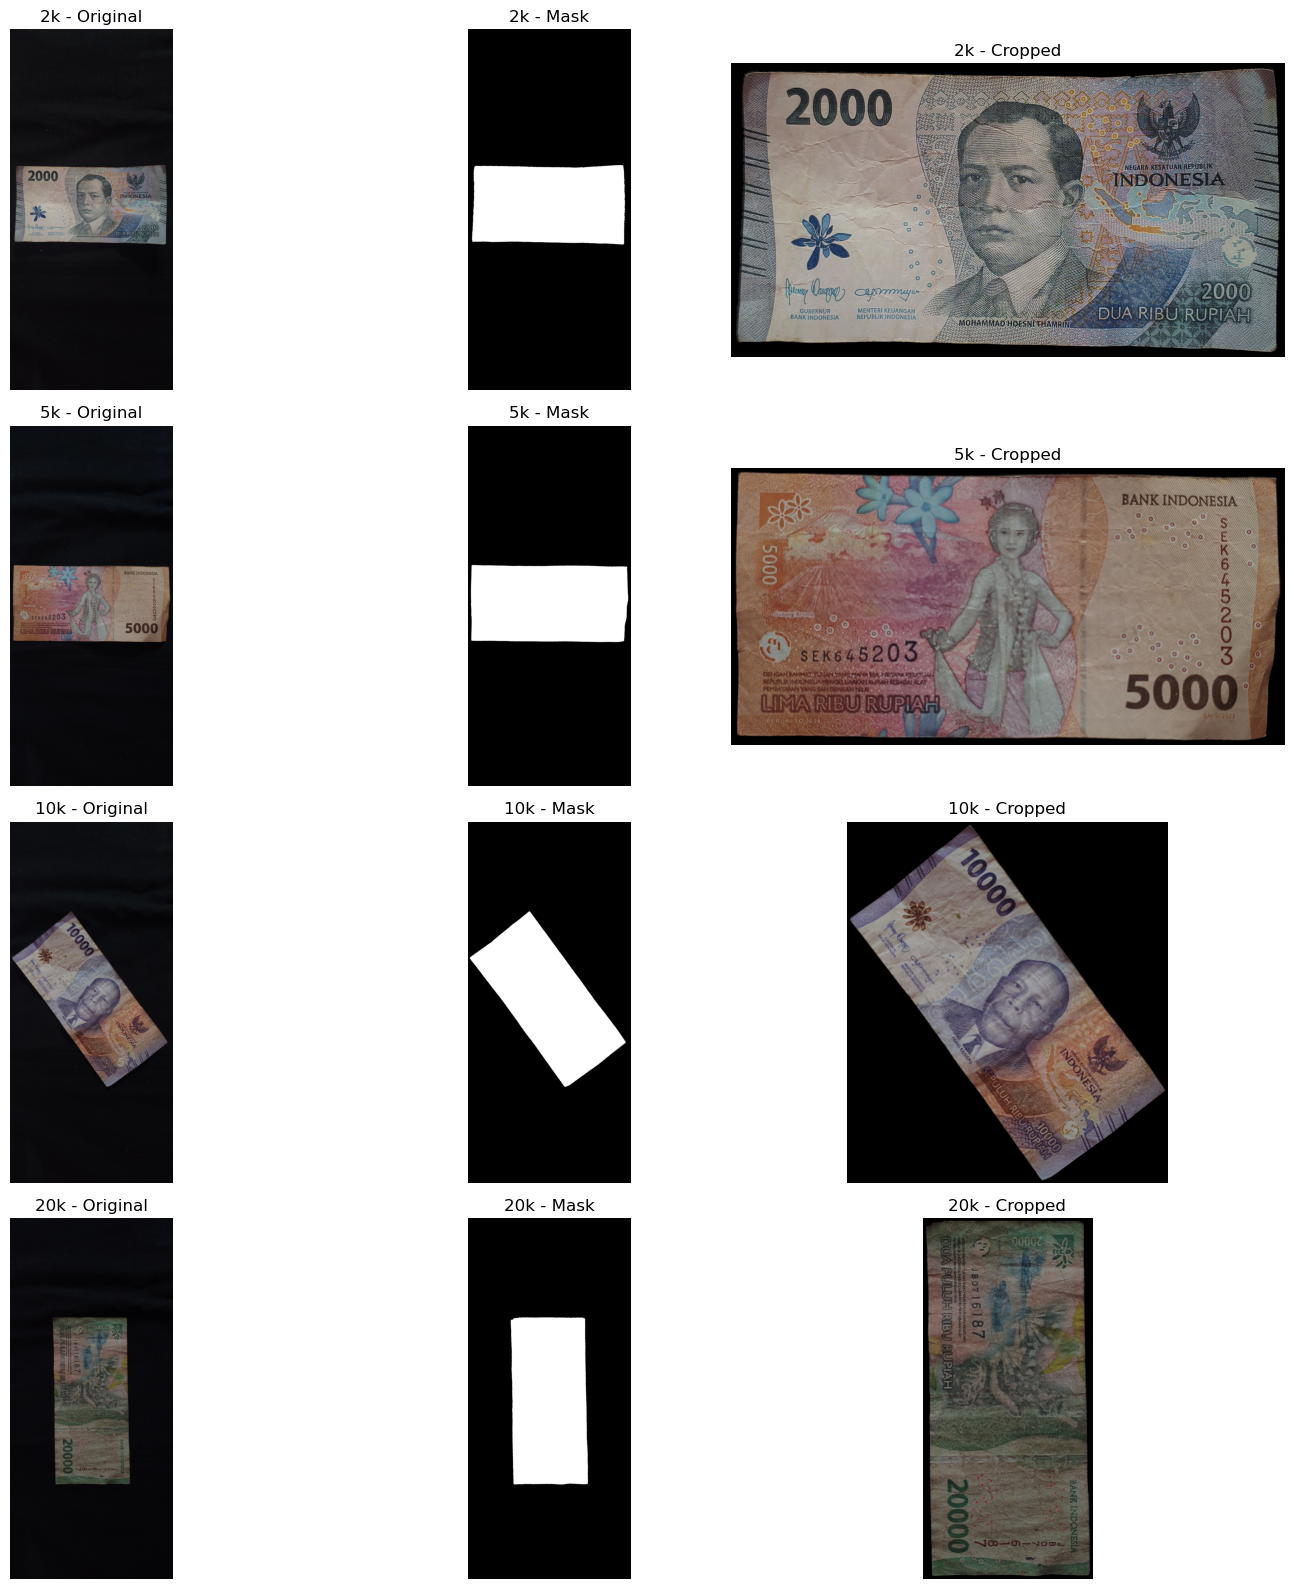

In [12]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Konfigurasi ──────────────────────────────────────────────
DATASET_DIR = Path("Dataset")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if (DATASET_DIR / d).is_dir()
])

print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", len(CLASS_NAMES))


# =========================
# 1) CLAHE pada channel V
# =========================
def apply_clahe_v(image_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    v = clahe.apply(v)

    hsv_clahe = cv2.merge([h, s, v])
    return cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2BGR)


# =========================
# 2) Segmentasi background gelap
# =========================
def segment_money_dark_bg(
    image_bgr,
    gray_threshold=25,
    min_area_ratio=0.01,
    kernel_size=7,
    use_clahe=False
):
    if image_bgr is None:
        raise ValueError("Gambar tidak berhasil dibaca.")

    work_img = image_bgr.copy()

    if use_clahe:
        work_img = apply_clahe_v(work_img)

    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, gray_threshold, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    h, w = mask.shape[:2]
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    flood_inv = cv2.bitwise_not(flood)
    mask = mask | flood_inv

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

        min_area = int(min_area_ratio * h * w)
        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    result = cv2.bitwise_and(work_img, work_img, mask=refined)
    return work_img, refined, result


# =========================
# 3) Crop berdasarkan mask
# =========================
def crop_to_mask(image_bgr, mask, padding=15):
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image_bgr

    x, y, w, h = cv2.boundingRect(coords)
    h_img, w_img = image_bgr.shape[:2]

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + w + padding, w_img)
    y2 = min(y + h + padding, h_img)

    return image_bgr[y1:y2, x1:x2]


# =========================
# 4) Tampilkan sample dari beberapa kelas
# =========================
def show_samples_by_class(
    class_list,
    samples_per_class=1,
    use_clahe=False,
    gray_threshold=25
):
    chosen_classes = class_list

    n_rows = len(chosen_classes)
    n_cols = 3  # Original, Mask, Cropped

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

    # Kalau hanya 1 kelas, axes perlu dipaksa jadi 2D
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, cls_name in enumerate(chosen_classes):
        class_path = DATASET_DIR / cls_name
        image_files = sorted([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

        if len(image_files) == 0:
            continue

        # Ambil 1 sampel random dari kelas tersebut
        sample_file = random.choice(image_files)
        img_path = class_path / sample_file
        img = cv2.imread(str(img_path))

        work_img, mask, segmented = segment_money_dark_bg(
            img,
            gray_threshold=gray_threshold,
            min_area_ratio=0.01,
            kernel_size=7,
            use_clahe=use_clahe
        )

        cropped = crop_to_mask(segmented, mask, padding=15)

        axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"{cls_name} - Original")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"{cls_name} - Mask")

        axes[i, 2].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        axes[i, 2].set_title(f"{cls_name} - Cropped")

        for j in range(n_cols):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# 5) Jalankan
# =========================
selected_classes = ["2k", "5k", "10k", "20k"]

show_samples_by_class(
    selected_classes,
    use_clahe=False,      # coba False dulu
    gray_threshold=25
)